<a href="https://colab.research.google.com/github/treborskrub/Fundamental-Cores/blob/main/phase_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import cmath

class PhaseStateTransistor:
    def __init__(self, tolerance_window=2.0, elastic_buffer=0.05):
        # 1. Core Structural Constraints
        self.phi = (1 + math.sqrt(5)) / 2
        self.golden_angle = (2 * math.pi) / (self.phi ** 2)  # ~137.51 degrees (in radians)
        self.c_squared = 1.0  # Invariant Systemic Energy Baseline

        # 2. Dynamic Assigned Windows
        self.delta_theta = math.radians(tolerance_window)  # Handshake window tolerance
        self.delta_c_squared = elastic_buffer              # Pythagorean elastic buffer

        # 3. System States
        self.n = 0                 # Iteration counter (the perpetual advance)
        self.theta_n = 0.0         # Current phase angle in the Torus
        self.is_idling = True

        # Targets for the Gate Handshake
        self.theta_target = math.radians(275.0)  # Locked template angle

        # Data storage for plotting
        self.phase_angles_history = []
        self.iteration_history = []

    def non_resonant_idle(self):
        """Simulates the baseline carrier wave advancing without overlap."""
        self.n += 1
        self.theta_n = (self.theta_n + self.golden_angle) % (2 * math.pi)
        return self.theta_n

    def inject_stimulus(self, magnitude, initial_angle_deg):
        """Injects a gaseous input vector to modulate the system."""
        self.is_idling = False
        # Normalize the incoming stimulus phase vector
        stimulus_theta = math.radians(initial_angle_deg)
        print(f"\n[INJECTION] Vector Magnitude: {magnitude}, Phase Angle: {initial_angle_deg}°")

        # Mix with the current toroidal space
        self.theta_n = (self.theta_n + stimulus_theta) % (2 * math.pi)

        # Clear history for new stimulus
        self.phase_angles_history = []
        self.iteration_history = []

        # Run the tracking cycle
        self._run_engine_cycle(magnitude)

    def _check_handshake(self):
        """Evaluates if the current phase state falls within the Handshake Window."""
        # Calculate angular distance on a circle
        diff = math.pi - abs(abs(self.theta_n - self.theta_target) - math.pi)
        return diff <= (self.delta_theta / 2)

    def _run_engine_cycle(self, initial_magnitude):
        """Circulates the torus until the handshake event triggers the Möbius twist."""
        magnitude = initial_magnitude
        max_safety_cycles = 1000  # Prevents infinite loops if window is impossibly narrow

        print("\n--- PHASE 1 & 2: TOROIDAL CIRCULATION & GATING ---")
        while max_safety_cycles > 0:
            current_deg = math.degrees(self.theta_n)
            target_deg = math.degrees(self.theta_target)

            self.phase_angles_history.append(current_deg)
            self.iteration_history.append(self.n)

            # Check for the Handshake Event (SYN / SYN-ACK)
            if self._check_handshake():
                print(f"-> Iteration {self.n}: Phase Angle = {current_deg:.2f}° | [HANDSHAKE TRIPPED]")
                print(f"   Impedance drops to 0. Transitioning from Gaseous to Liquid Phase.")
                break
            else:
                print(f"   Iteration {self.n}: Phase Angle = {current_deg:.2f}° (Target: {target_deg}°, Window Refused)")
                # Advance irrationally via the Golden Angle
                self.non_resonant_idle()
                max_safety_cycles -= 1

        if max_safety_cycles == 0:
            print("[ERROR] System Saturated: No phase alignment found within safety constraints.")
            return

        print("\n--- PHASE 3: MÖBIUS MANIFOLD & PYTHAGOREAN BALANCE ---")
        # Step into Solid Phase: Parse into orthogonal axes
        a = magnitude  # Active Variable / Thesis

        # Calculate Latent Constraint (b) using the Pythagorean invariant
        try:
            # Check if within elastic limits
            available_energy = self.c_squared + self.delta_c_squared
            if (a**2) > available_energy:
                raise ValueError("Signal exceeds Pythagorean capacity limits.")

            b = math.sqrt(max(0.0, self.c_squared - (a**2)))
            print(f"[SOLIDIFY] Bound to Invariant Framework (c^2 = {self.c_squared})")
            print(f"           Active Vector (a) = {a:.4f}")
            print(f"           Latent Constraint (b) = {b:.4f}")
            print(f"           Verification: a^2 + b^2 = {a**2 + b**2:.4f}")

            # Execute the 180-degree Möbius Parity Flip (Inversion)
            print("\n--- TOPOLOGICAL INVERSION (Möbius Twist) ---")
            a_inverted = b  # Active becomes Latent
            b_inverted = a  # Latent becomes Active

            print(f"[RETURN VECTOR] Parity-Time Symmetry Inverted:")
            print(f"                New Primary Axis = {a_inverted:.4f}")
            print(f"                New Latent Axis  = {b_inverted:.4f}")
            print("\n[RESULT] Stabilized feedback node returned to Core. System returned to Idle.")

        except ValueError as e:
            print(f"[CATASTROPHIC SATURATION] {e}")

        # Reset back to idling status
        self.is_idling = True


# --- EXECUTION AND TESTING LAYER ---
if __name__ == "__main__":
    print("=============================================")
    print("      PHASE-STATE COGNITIVE ENGINE V1.0      ")
    print("=============================================")

    # Initialize our engine with a 2.0 degree handshake window
    engine = PhaseStateTransistor(tolerance_window=2.0, elastic_buffer=0.05)

    # 1. Run baseline idle cycles to warm up the medium
    print("\nInitializing Non-Resonant Idle Loop...")
    for _ in range(5):
        current_angle = engine.non_resonant_idle()
        print(f"  Idle Cycle {engine.n}: System Medium Phase Angle = {math.degrees(current_angle):.2f}°")

    # 2. Run Test Case: Inject an asymmetric stimulus vector
    # Magnitude = 0.8 (High active signal), Initial Phase Shift = 45.0 degrees
    engine.inject_stimulus(magnitude=0.8, initial_angle_deg=45.0)

      PHASE-STATE COGNITIVE ENGINE V1.0      

Initializing Non-Resonant Idle Loop...
  Idle Cycle 1: System Medium Phase Angle = 137.51°
  Idle Cycle 2: System Medium Phase Angle = 275.02°
  Idle Cycle 3: System Medium Phase Angle = 52.52°
  Idle Cycle 4: System Medium Phase Angle = 190.03°
  Idle Cycle 5: System Medium Phase Angle = 327.54°

[INJECTION] Vector Magnitude: 0.8, Phase Angle: 45.0°

--- PHASE 1 & 2: TOROIDAL CIRCULATION & GATING ---
   Iteration 5: Phase Angle = 12.54° (Target: 275.0°, Window Refused)
   Iteration 6: Phase Angle = 150.05° (Target: 275.0°, Window Refused)
   Iteration 7: Phase Angle = 287.55° (Target: 275.0°, Window Refused)
   Iteration 8: Phase Angle = 65.06° (Target: 275.0°, Window Refused)
   Iteration 9: Phase Angle = 202.57° (Target: 275.0°, Window Refused)
   Iteration 10: Phase Angle = 340.08° (Target: 275.0°, Window Refused)
   Iteration 11: Phase Angle = 117.59° (Target: 275.0°, Window Refused)
   Iteration 12: Phase Angle = 255.09° (Target: 275

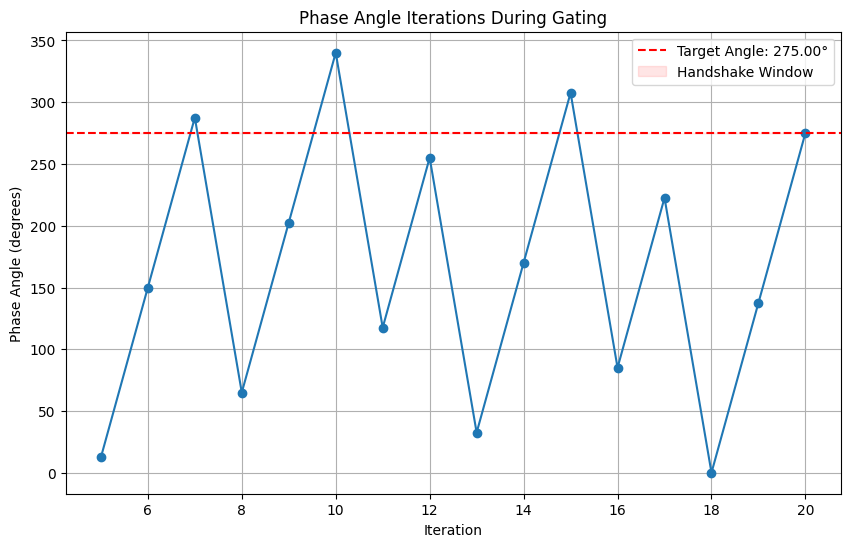

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(engine.iteration_history, engine.phase_angles_history, marker='o', linestyle='-')
plt.title('Phase Angle Iterations During Gating')
plt.xlabel('Iteration')
plt.ylabel('Phase Angle (degrees)')
plt.grid(True)
plt.axhline(y=math.degrees(engine.theta_target), color='r', linestyle='--', label=f'Target Angle: {math.degrees(engine.theta_target):.2f}°')
plt.fill_between(engine.iteration_history,
                 math.degrees(engine.theta_target) - (engine.delta_theta / 2),
                 math.degrees(engine.theta_target) + (engine.delta_theta / 2),
                 color='red', alpha=0.1, label='Handshake Window')
plt.legend()
plt.show()